# A Promised Park, Two Vacant Lots, and 1,254 Votes

In [1]:
import json, re
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import re

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import mannwhitneyu, spearmanr

SURFACE, INK, INK2 = "#fcfcfb", "#0b0b0b", "#52514e"
BLUE, RED, GRAY = "#2a78d6", "#e34948", "#8a8983"
# darker variants for text so labels meet WCAG contrast on SURFACE
BLUETXT, REDTXT, GRAYTXT = "#1f62b4", "#c22a29", "#6e6d68"
SRC = "Source: Brooklyn Community Board 1 meeting minutes"
pd.set_option("display.max_colwidth", 200)
con = duckdb.connect()
for t in ("meetings", "licenses", "votes", "speakers", "incidents", "cannabis"):
    con.execute(f"CREATE VIEW {t} AS SELECT * FROM '../data/db/{t}.parquet'")

def q(sql):
    return con.execute(sql).df()

# full-text index: meeting_id -> complete minutes text (text layer + vision OCR)
_meet = json.loads(Path("../data/meetings.json").read_text())["meetings"]
_sha2mid = {f["sha256"]: mid for mid, m in _meet.items() for f in m["files"]}
_texts = {}
for _tf in Path("../data/interim/text").glob("*.json"):
    _mid = _sha2mid.get(_tf.stem)
    if _mid:
        _texts[_mid] = _texts.get(_mid, "") + " " + " ".join(json.loads(_tf.read_text()))
for _of in Path("../data/interim/ocr").glob("*.txt"):
    _mid = _sha2mid.get(_of.name[:64])
    if _mid:
        _texts[_mid] = _texts.get(_mid, "") + " " + _of.read_text()
_lower = {m: t.lower() for m, t in _texts.items()}
_dates = {m: v["date"] for m, v in _meet.items()}
lower = _lower
dates = _dates
def mentions(term):
    """Meetings where `term` appears, with counts. Case-insensitive."""
    term = term.lower()
    return pd.DataFrame(
        [(m, _dates[m], _lower[m].count(term)) for m in _lower if term in _lower[m]],
        columns=["meeting_id", "date", "n"],
    ).sort_values("date").reset_index(drop=True)

def context(term, meeting_id, width=200, k=5):
    """Verbatim passages around each occurrence of `term` in one meeting."""
    out = []
    for m in re.finditer(re.escape(term.lower()), _lower[meeting_id]):
        s = max(0, m.start() - width)
        out.append(" ".join(_texts[meeting_id][s : m.end() + width].split()))
        if len(out) >= k:
            break
    return out

print(f"{len(_texts)} meetings indexed, {sum(len(t) for t in _texts.values())/1e6:.0f}M chars")
wf = pd.DataFrame(
    [(m, _meet[m]["date"], _lower[m].count("waterfront")) for m in _lower],
    columns=["meeting_id", "date", "wf_mentions"],
)
wf["date"] = pd.to_datetime(wf.date)
wf_meetings = wf[wf.wf_mentions > 0].sort_values("date").reset_index(drop=True)


110 meetings indexed, 31M chars


![Bushwick Inlet Park from the community center's green roof, April 2026: the soccer field in use on the left - and one of the two vacant lots on the right. Photo: author](images/bip_and_lots.jpg){.column-screen style="width:80%;margin:0 auto;display:block;" fig-alt="View from a green roof: a full soccer field on the left and a flat, empty asphalt lot on the right, with the East River and Manhattan skyline behind."}


::: {.tldr}
**TLDR:** There are large waterfront lots in North Williamsburg that are zoned as public parks but are currently vacant. I conducted a data study to learn how the community has shown up to advocate for change.

In 10 years of meeting notes from the local community board for North Brooklyn (Community Board 1) we can see that way public speakers at community meetings advocate correlates with the way the board votes.
:::


## The backstory

![Navy airplanes over Greenpoint, May 1930. The piers, rail yards, and tank farms below are the land in focus for this article. Photo: [U.S. National Archives](https://commons.wikimedia.org/wiki/File:New_York_-_Brooklyn_-_NARA_-_68145045.jpg), public domain](images/aerial_1930_web.jpg){.column-body-outset fig-alt="Black-and-white 1930 aerial photo of Navy biplanes flying over the Greenpoint waterfront's piers, rail yards, and tank farms."}


Williamsburg has become a neighborhood synonmous with gentrification. The median household income more than doubled: from $52,710 in 2000 (in 2025 dollars) to $110,480 in 2024 ([Furman Center](https://furmancenter.org/neighborhoods/view/greenpoint-williamsburg)) and population grew by more than a third: from about 160k residents in 2000 to 219k in 2024 ([Census](https://www.nyc.gov/assets/planning/download/pdf/data-maps/census/census2000/1990-2000_bk_cd_profile.pdf), [Furman Center](https://furmancenter.org/neighborhoods/view/greenpoint-williamsburg)). A poignant example: the old Domino Sugar Factory sat vacant for nearly two decades after closing in 2004, and reopened in 2023 as home to modern offices and a luxury Equinox gym.

I recently moved to Williamsburg and was surprised by large waterfront lots sitting vacant between N 10th and N 14th Streets, right in front of my apartment. With so much development nearby, I was curious how this land could be ignored. It turns out there has been a plan for this land since 2005. That's when Mayor Bloomberg made a deal to rezone the North Brooklyn waterfront. The plan allowed the building of luxury high-rise residential towers increasing land value for private owners and promised a waterfront park for the community on the exact lots that I was curious about (on the right in the first picture). Since then, the waterfront high-rises have been built. Yet, we still only have a portion of the promised 28-acre park in Bushwick Inlet Park.

It's been two decades, what gives?

## Scraping the minutes

Brooklyn Community Board 1 (CB1), the local advisory board for Williamsburg and Greenpoint, is the most relevant government body for this area. Every land use application has to come through CB1 for a public hearing and a recommendation before the city makes a decision. Lucky for me, CB1 posts its [meeting minutes online](https://www.nyc.gov/site/brooklyncb1/meetings/minutes.page). I created a script to scan the PDFs and build a dataset of the key data points for these meetings. The dataset covers all of CB1's 110 meetings, 1,254 votes, and 1,369 speakers. Below we can see how often the term 'waterfront' shows up in these notes. 



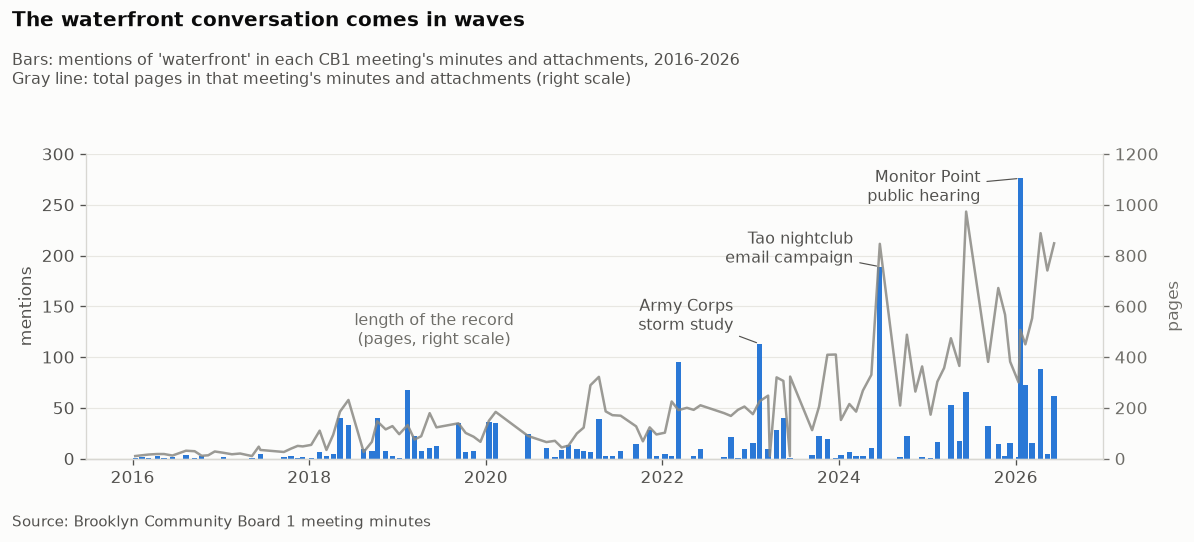

In [2]:
#| fig-alt: "Bar chart of waterfront mentions per CB1 meeting, 2016 to 2026. Mostly small bars with spikes labeled Army Corps storm study (113 mentions, 2023), Tao nightclub email campaign (189, 2024), and Monitor Point public hearing (276, 2026). A gray line on a right-hand scale shows each meeting's minutes growing from about 20 pages in 2016 to several hundred by 2026."
#| column: body-outset
# pages per meeting: how thick the minutes themselves got over the decade
_pages = {}
for _mid, _m in _meet.items():
    _n = 0
    for _f in _m["files"]:
        _tp = Path(f"../data/interim/text/{_f['sha256']}.json")
        if _tp.exists():
            _n += len(json.loads(_tp.read_text()))
    _pages[_mid] = _n
wf["pages"] = wf.meeting_id.map(_pages)

fig, ax = plt.subplots(figsize=(10, 4.2), dpi=120)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
ax.bar(wf_meetings.date, wf_meetings.wf_mentions, width=22, color=BLUE)
for d, v, label, off in [("2026-01-20", 276, "Monitor Point\npublic hearing", (-24, 6)),
                         ("2024-06-18", 189, "Tao nightclub\nemail campaign", (-16, 22)),
                         ("2023-02-07", 113, "Army Corps\nstorm study", (-16, 28))]:
    ax.annotate(label, (pd.Timestamp(d), v), xytext=off,
                textcoords="offset points", ha="right", va="top",
                fontsize=9.5, color=INK2,
                arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
ax.set_ylim(0, 300)
ax.set_ylabel("mentions", fontsize=10, color=INK2)
ax.tick_params(colors=INK2, labelsize=10)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.spines["left"].set_color("#d8d7d2"); ax.spines["bottom"].set_color("#d8d7d2")
ax.grid(axis="y", color="#e8e7e2", lw=0.7); ax.set_axisbelow(True)

# right scale: the minutes' own length - the mentions' denominator in plain sight
axp = ax.twinx()
_ws = wf.sort_values("date")
axp.plot(_ws.date, _ws.pages, color=GRAY, lw=1.5, alpha=0.85)
axp.set_ylim(0, 1200)
axp.set_yticks(range(0, 1201, 200))
axp.set_ylabel("pages", fontsize=10, color=GRAYTXT)
axp.tick_params(colors=GRAYTXT, labelsize=10)
for s in ("top", "left"):
    axp.spines[s].set_visible(False)
axp.spines["right"].set_color("#d8d7d2")
axp.spines["bottom"].set_color("#d8d7d2")
axp.annotate("length of the record\n(pages, right scale)",
             (pd.Timestamp("2019-06-01"), 430), fontsize=9.5, color=GRAYTXT,
             ha="center", va="bottom")

fig.suptitle("The waterfront conversation comes in waves",
             fontsize=12, color=INK, x=0.01, ha="left", fontweight="bold")
fig.text(0.01, 0.90, "Bars: mentions of 'waterfront' in each CB1 meeting's minutes and attachments, 2016-2026\n"
         "Gray line: total pages in that meeting's minutes and attachments (right scale)",
         fontsize=9.5, color=INK2, va="top")
fig.text(0.01, -0.02, "Source: Brooklyn Community Board 1 meeting minutes",
         fontsize=9, color=INK2, va="top")
fig.tight_layout(rect=[0, 0, 1, 0.82])
plt.show()

The term "waterfront" shows up frequently (the blue bars), with a few spikes in activity. These spikes get larger over time. The gray line  shows that the length of the minutes themselves has also grown over the last decade. This is largely because the board office started binding testimony and correspondence into the record circa 2024. To get a sense of what actually happens in these meetings and the level of detail in the notes, here's a summary of the latest two spikes:

January 20, 2026 — 276 "waterfront" mentions. This is a public hearing focused exclusively on Monitor Point. The notes are mostly written testimony from individuals and community groups including Veronica Zapasnik, a Polish immigrant who's been in the neighborhood since 1990, and NYSAFAH (the New York State Association for Affordable Housing). The pro-park testimonies repeat one claim: the rezoning of this land into a set of residential towers breaks a two-decade-old promise to make it a waterfront park for all.

June 18, 2024 — 189 "waterfront" mentions. There is a swarm of emails to the board about the proposal to open a Tao nightclub next to Bushwick Inlet Park, including one template that was re-sent over 100 times. The template focuses on the habitat restoration at the Inlet and the noise pollution a club would bring.

## Showing up - at the mic and in writing

The dataset of CB1 meetings measures the two main ways the community can voice their opinions: public speakers showing up physically to the board meetings and written testimony to the board. Public speakers are permitted at the board meetings after pre-approval for an allotment of 2-3 minutes per speaker. Alternatively, written testimony is accepted via email or letter. The actual letters and emails only show up in our dataset in volume in the last few years - more on that below.

I wanted to get a sense of which side shows up to speak vs how the board votes. Below we examine a few board votes through that lens.

In [3]:
# mail dataset (feeds the mail/room chart and the consistency guard).
# Items were split from the minutes' attachment pages by an LLM pass —
# data/mail_items.jsonl holds one record per letter/email with its first
# 1,200 chars (email addresses redacted) and, for the four charted fights,
# an adjudicated fight tag. Stances are keyword-coded HERE from each item's
# window; documented adjudications (data/mail_adjudications.jsonl — every
# minority-class item read and confirmed) override the keywords where they
# misfire. See methodology.
MAIL_AGAINST = re.compile(
    r"oppos|against|deny|denial|disapprov|reject|do not approve|vote no|say no|"
    r"no to |no more |stop (?:the|this)|not support|withdraw|concern|"
    r"urge.{0,60}(?:deny|vote no|no\b)", re.I)
MAIL_FOR = re.compile(
    r"\bsupport(?!er)|in favor|\bapprove|endorse|urge.{0,60}(?:approve|yes\b)|"
    r"vote yes|stand with", re.I)
# negated pro-phrases read as opposition ("cannot support", "not approve", ...)
MAIL_NEG = re.compile(
    r"(?:\bcannot|\bnot|n't|\bnever)\s+(?:support|approve|endorse)\w*", re.I)

def _mail_stance(txt):
    t = re.sub(r"[‘’“”\"']", "", txt)
    t = re.sub(r"to whom it may concern", " ", t, flags=re.I)
    t = MAIL_NEG.sub(" oppose ", t)
    a, f = len(MAIL_AGAINST.findall(t)), len(MAIL_FOR.findall(t))
    if a and f:  # both directions present: writers lead with their stance
        return ("against" if MAIL_AGAINST.search(t).start()
                < MAIL_FOR.search(t).start() else "for")
    return "against" if a > f else "for" if f > a else "unclear"

_items = [json.loads(_l) for _l in Path("../data/mail_items.jsonl").read_text().splitlines()]
_adj = {_a["key"]: _a for _a in
        (json.loads(_l) for _l in Path("../data/mail_adjudications.jsonl").read_text().splitlines())}
_rows = []
for _r in _items:
    _c = _adj.get(_r["key"], {}).get("confirmed")
    if _c == "exclude":
        continue
    _fights = list(_r.get("fights") or [])
    _stance = None if _r["outgoing"] else _mail_stance(_r["window"])
    if _c in ("untag", "untag-unclear"):
        _fights = []
        if _c == "untag-unclear":
            _stance = "unclear"
    elif _c in ("for", "against", "unclear"):
        _stance = _c
    _rows.append((_r["meeting_id"], _r["date"], _r["window"],
                  _r["outgoing"], _stance, _fights))
MAIL = pd.DataFrame(_rows, columns=["mid", "date", "text", "outgoing", "stance", "fights"])
INCOMING = MAIL[~MAIL.outgoing].reset_index(drop=True)

# a letter's subject lives in its header/opening; stored windows are the
# first 1,200 chars, so subject matching scans the whole stored text
def _about(sub_df, pat):
    subj = re.compile(pat, re.I)
    return sub_df[sub_df.text.map(lambda t: bool(subj.search(t[:1200])))]

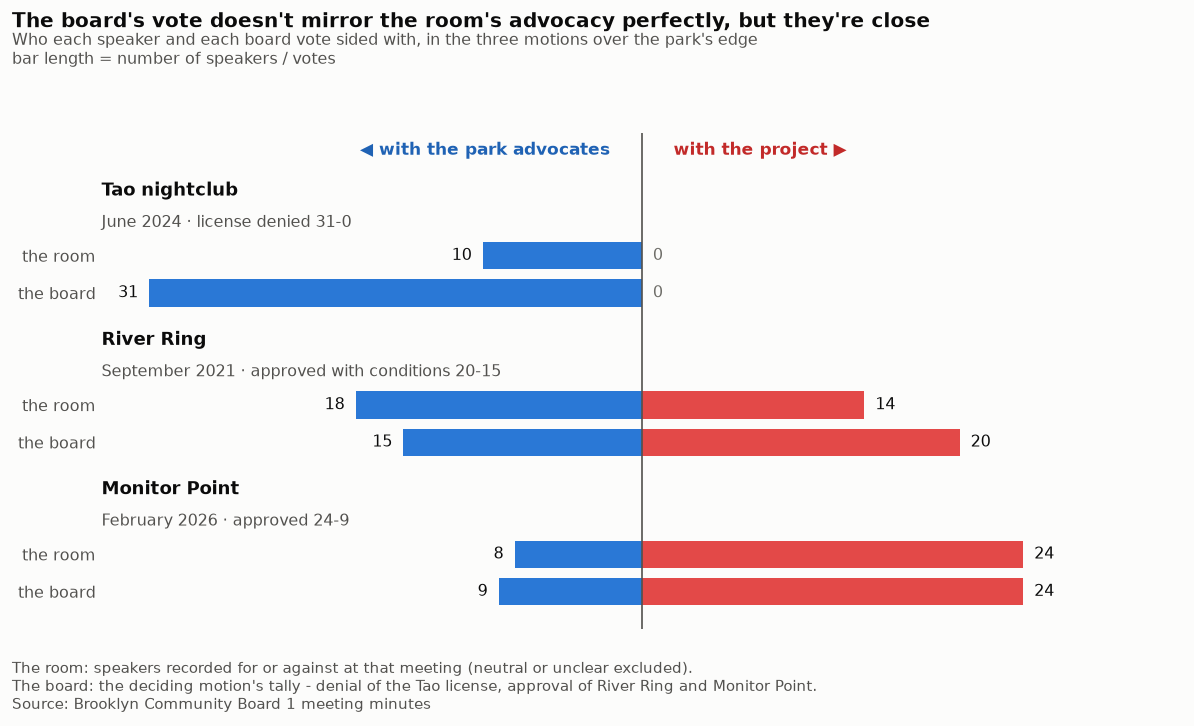

In [4]:
#| fig-alt: "Diverging bar chart of three motions: Tao nightclub, River Ring, and Monitor Point. For each, one row shows the room's speakers and one the board's votes, split between the park advocates' side and the project's side. The board sides with the room at Tao (10-0 room, 31-0 board) and Monitor Point (24-8 room for the project, 24-9 board); at River Ring an 18-14 room against faces a 20-15 board in favor."
#| column: body-outset
# Three fights over the park's edge, from the park advocates' side.
# In each one the advocates opposed the project, so a speaker "against" and a
# board vote against approval both count as siding with the park. The deciding
# motion at Tao was a denial, so there the yes votes are the advocates' side.
def room(date, pat):
    d = q(f"""SELECT position, count(*) AS n
              FROM speakers s JOIN meetings m USING (meeting_id)
              WHERE m.date = '{date}' AND regexp_matches(lower(s.topic), '{pat}')
              GROUP BY 1""").set_index("position").n
    return int(d.get("against", 0)), int(d.get("for", 0))

def board(date, pat):
    v = q(f"""SELECT yes, no FROM votes v JOIN meetings m USING (meeting_id)
              WHERE m.date = '{date}'
                AND regexp_matches(lower(v.motion_text), '{pat}')""")
    assert len(v) == 1
    return int(v.iloc[0].yes), int(v.iloc[0].no)

deny_y, deny_n = board("2024-06-18", "deny the application for franklin")
rr_y, rr_n = board("2021-09-14", "yes with the committee.s conditions")
mp_y, mp_n = board("2026-02-10", "to approve application monitor point")

fights = [
    ("Tao nightclub", "June 2024 · license denied 31-0",
     room("2024-06-18", "franklin"), (deny_y, deny_n)),
    ("River Ring", "September 2021 · approved with conditions 20-15",
     room("2021-09-14", "river ring"), (rr_n, rr_y)),
    ("Monitor Point", "February 2026 · approved 24-9",
     room("2026-02-10", "monitor point"), (mp_n, mp_y)),
]

fig, ax = plt.subplots(figsize=(10, 5.4), dpi=120)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

ys, ylabels = [], []
for g, (name, sub, (r_adv, r_proj), (b_adv, b_proj)) in enumerate(fights):
    y0 = g * 3.4
    ax.text(-34, y0 - 0.78, name, fontsize=11, color=INK, fontweight="bold",
            ha="left", va="center")
    ax.text(-34, y0 - 0.05, sub, fontsize=9.5, color=INK2, ha="left", va="center")
    for row, (adv, proj) in enumerate([(r_adv, r_proj), (b_adv, b_proj)]):
        y = y0 + 0.7 + row * 0.85
        ax.barh(y, -adv, height=0.62, color=BLUE)
        ax.barh(y, proj, height=0.62, color=RED)
        ax.annotate(str(adv), (-adv - 0.7, y), ha="right", va="center",
                    fontsize=9.5, color=INK if adv else GRAYTXT)
        ax.annotate(str(proj), (proj + 0.7, y), ha="left", va="center",
                    fontsize=9.5, color=INK if proj else GRAYTXT)
        ys.append(y)
        ylabels.append("the room" if row == 0 else "the board")

ax.axvline(0, color=INK2, lw=1)
ax.set_yticks(ys, ylabels, fontsize=9.5)
ax.set_ylim(9.2, -2.1)
ax.set_xlim(-34, 34)
ax.set_xticks([])
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
ax.tick_params(colors=INK2, length=0)
ax.annotate("◀ with the park advocates", (-2, -1.6), ha="right",
            fontsize=10, color=BLUETXT, fontweight="bold")
ax.annotate("with the project ▶", (2, -1.6), ha="left",
            fontsize=10, color=REDTXT, fontweight="bold")
fig.suptitle("The board's vote doesn't mirror the room's advocacy perfectly, but they're close",
             fontsize=12, color=INK, x=0.01, ha="left", fontweight="bold")
fig.text(0.01, 0.9, "Who each speaker and each board vote sided with, in the three motions over the park's edge\n"
         "bar length = number of speakers / votes",
         fontsize=9.5, color=INK2)
fig.text(0.01, -0.02, "The room: speakers recorded for or against at that meeting (neutral or unclear excluded).\n"
         "The board: the deciding motion's tally - denial of the Tao license, approval of River Ring and Monitor Point.\n"
         + SRC,
         fontsize=9, color=INK2, va="top")
fig.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

This chart zooms in on 3 board motions over the future of parks in North Brooklyn.  Each motion has 2 corresponding rows: who spoke at the hearing, and how the board voted.

The board's split tracks the room's split but not perfectly. The park advocates' one win (Tao nightclub) came when nobody showed up for the other side - ten speakers against and zero for it. The board denied the license 31-0. At Monitor Point the flow ran the other way: the project side filled the room 24-8, and the board landed at 24-9, almost the same ratio. River Ring is the only motion where the board varied from the room's position but it was still close - the room was 18-14 against and the board 20-15 in favor. 

This is a small sample, but it shows the board voting close to how the room splits. Even in River Ring, the one loss for the park advocates, the ratios are similar. 

## What about the letters?

Speaking at the mic isn't the only way to reach the board, community members can write emails or letters to CB1. The meeting minutes bind these letters and emails into the public record. The minutes bind 1,707 letters and emails across the 110 meetings. 464 are the board's own outgoing mail, which I exclude from this analysis. The remaining 1,243 pieces of incoming correspondence still cluster heavily in recent years - 72% land from 2024 on. 


Below I create a similar visual to above but this time including mail. I used an LLM to classify each piece of written testimony as for or against the motion and  match the letter to the motion it relates to. The 4 motions included below are the only 4 that are both relevant to CB1 and contain reasonable written testimony (a fifth, the Maiz license, drew only a handful of one-sided complaints about one venue's noise and is left out).

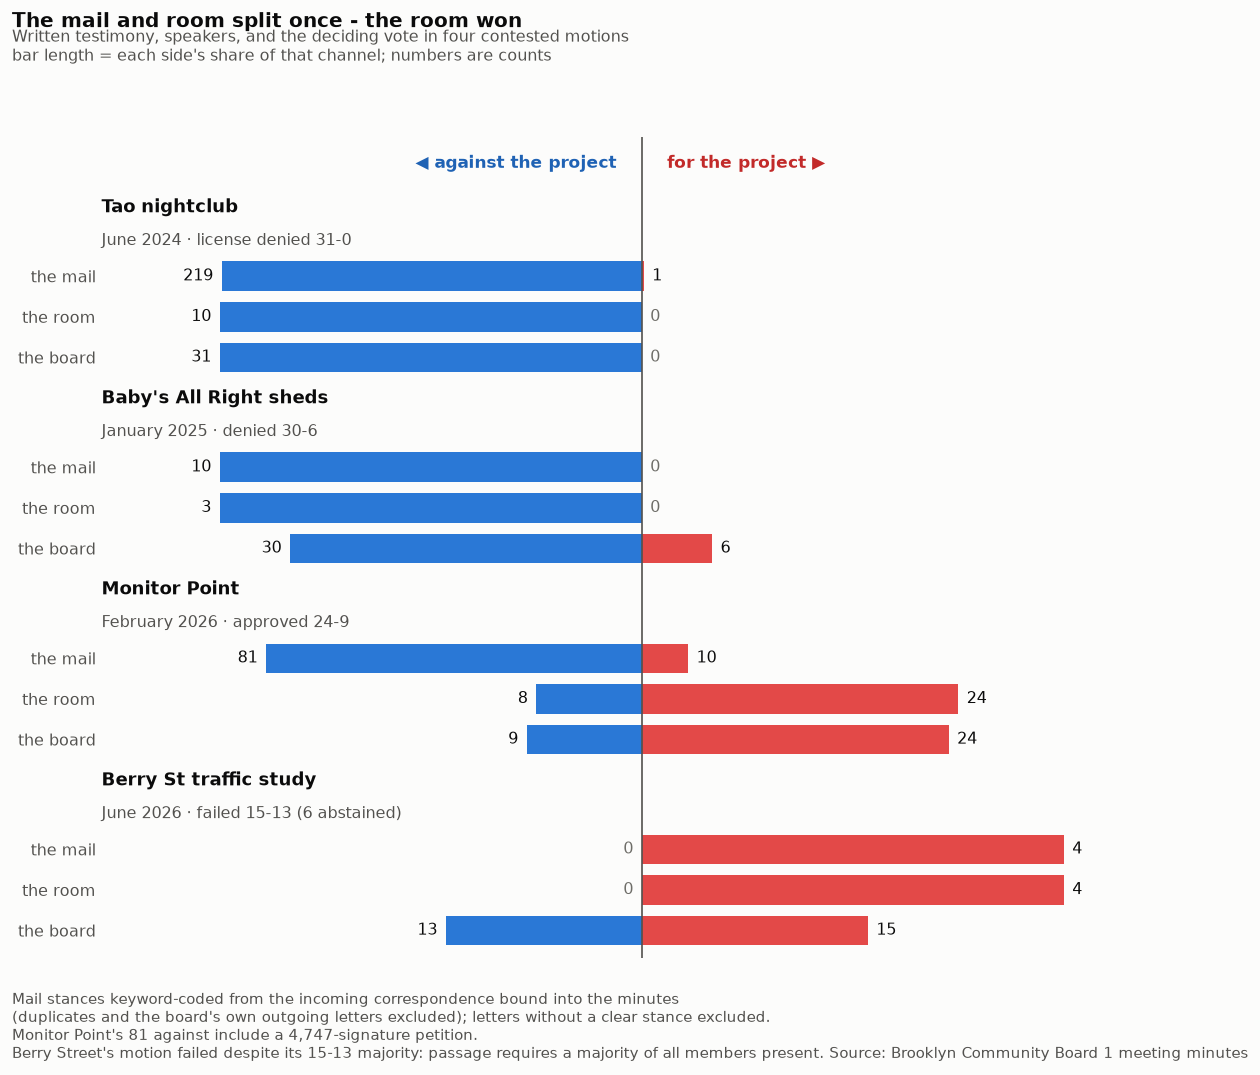

In [5]:
#| fig-alt: "Diverging bar chart of four motions: Tao nightclub, Baby's All Right sheds, Monitor Point, and the Berry Street traffic study. Rows show the mail, the room, and the board split for and against each project. Mail runs against in the first three (Tao 219-1, sheds 10-0, Monitor Point 81-10) and unanimously for the Berry Street study (4-0). At Monitor Point the room runs in favor (24-8) and the board lands 24-9 with the room; at Berry Street mail and room are unanimous in favor and the board splits 15-13 for, but the motion fails for lack of an absolute majority."
#| column: body-outset
# The mail, with direction: count the incoming items carrying each fight's
# adjudicated tag (dataset above) by their coded stance. Every letter
# charted as 'for' below was read and confirmed; items whose stance can't
# be called are excluded (see methodology).
def mail_counts(fight):
    s = INCOMING[INCOMING.fights.map(lambda f: fight in f)].stance.value_counts()
    return int(s.get("against", 0)), int(s.get("for", 0))

tao_y, tao_n = board("2024-06-18", "deny the application for franklin")
ba_y, ba_n = board("2025-01-14", "outside shed")
br_y, br_n = board("2026-06-09", "berry")  # 15-13, failed: absolute majority required
# mp_y/mp_n (approve motion) already computed for the three-fights chart
mp_mail = mail_counts("monitor_point")
tao_mail = mail_counts("tao")
berry_mail = mail_counts("berry")
assert tao_mail[0] > 100 and mp_mail[0] > 3 * mp_mail[1], (tao_mail, mp_mail)

# (name, sub, mail(against,for), room(against,for), board(against,for))
MAIL_FIGHTS = [
    ("Tao nightclub", "June 2024 · license denied 31-0",
     tao_mail, room("2024-06-18", "franklin"), (tao_y, tao_n)),
    ("Baby's All Right sheds", "January 2025 · denied 30-6",
     mail_counts("babys"),
     room("2025-01-14", "baby.s all right|146 broadway|outdoor dining"), (ba_y, ba_n)),
    ("Monitor Point", "February 2026 · approved 24-9",
     mp_mail, room("2026-02-10", "monitor point"), (mp_n, mp_y)),
    ("Berry St traffic study", "June 2026 · failed 15-13 (6 abstained)",
     berry_mail, room("2026-06-09", "berry"), (br_n, br_y)),
]

fig, ax = plt.subplots(figsize=(10, 8.2), dpi=120)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)
ys, ylabels = [], []
for g, (name, sub, (m_ag, m_for), (r_ag, r_for), (b_ag, b_for)) in enumerate(MAIL_FIGHTS):
    y0 = g * 4.0
    ax.text(-1.28, y0 - 0.72, name, fontsize=11, color=INK, fontweight="bold",
            ha="left", va="center")
    ax.text(-1.28, y0 - 0.02, sub, fontsize=9.5, color=INK2, ha="left", va="center")
    for row, (ag, fr) in enumerate([(m_ag, m_for), (r_ag, r_for), (b_ag, b_for)]):
        y = y0 + 0.72 + row * 0.85
        tot = ag + fr
        ax.barh(y, -ag / tot, height=0.62, color=BLUE)
        ax.barh(y, fr / tot, height=0.62, color=RED)
        ax.annotate(str(ag), (-ag / tot - 0.02, y), ha="right", va="center",
                    fontsize=9.5, color=INK if ag else GRAYTXT)
        ax.annotate(str(fr), (fr / tot + 0.02, y), ha="left", va="center",
                    fontsize=9.5, color=INK if fr else GRAYTXT)
        ys.append(y)
        ylabels.append(("the mail", "the room", "the board")[row])
ax.axvline(0, color=INK2, lw=1)
ax.set_yticks(ys, ylabels, fontsize=9.5)
ax.set_ylim(15.0, -2.2)
ax.set_xlim(-1.28, 1.28)
ax.set_xticks([])
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
ax.tick_params(colors=INK2, length=0)
ax.annotate("◀ against the project", (-0.06, -1.55), ha="right",
            fontsize=10, color=BLUETXT, fontweight="bold")
ax.annotate("for the project ▶", (0.06, -1.55), ha="left",
            fontsize=10, color=REDTXT, fontweight="bold")
fig.suptitle("The mail and room split once - the room won",
             fontsize=12, color=INK, x=0.01, ha="left", fontweight="bold")
fig.text(0.01, 0.925, "Written testimony, speakers, and the deciding vote in four contested motions\n"
         "bar length = each side's share of that channel; numbers are counts", fontsize=9.5, color=INK2, va="bottom")
fig.text(0.01, -0.015, "Mail stances keyword-coded from the incoming correspondence bound into the minutes\n"
         "(duplicates and the board's own outgoing letters excluded); letters without a clear stance excluded.\n"
         "Monitor Point's 81 against include a 4,747-signature petition.\nBerry Street's motion failed despite its 15-13 majority: passage requires a majority of all members present. " + SRC,
         fontsize=9, color=INK2, va="top")
fig.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

In the top two motions in the graphic above the letters, the mic, and the board all pointed the same way. For Tao, there were 219 emails against the nightclub, versus exactly one in favor (subject line: "Tao night club, yes please!"). 

Monitor Point is the only motion where the advocacy channels split. I want to be careful about drawing conclusions from one data point. But this motion provides a clue to answer which channel is more important: mail or in-person advocacy. The mail ran 81-10 against the rezoning, including a 4,747-signature petition. The room ran 24-8 in favor - union locals and the developer's own team filled the seats. The board went with the room, 24-9. The one time the mail and the mic clashed, the board went with the voices in the room.

The Berry Street Traffic study is the only outlier in that the outcome went against both the speakers and the mail. The mail and mic were unanimous for the study, the board's majority 15-13 went with the mail and the room, yet the motion still failed because passage requires a majority of all members present and six members abstained.

## Does the room predict the vote?

These relationships are interesting, but not statistically rigorous. To draw a statistical conclusion we need more data points than the four motions with mail - so I dropped the limitation of focusing on written testimony or just waterfront votes. The below analysis just focuses on the impact of which way speakers advocate. The graph below charts the result of a regression predicting the board's vote based on the ratio of public speakers' advocacy for vs. against a motion. Each of the 21 points in the graph below compares the proportion of the room in favor of a motion with the proportion of the board's votes in favor of it.

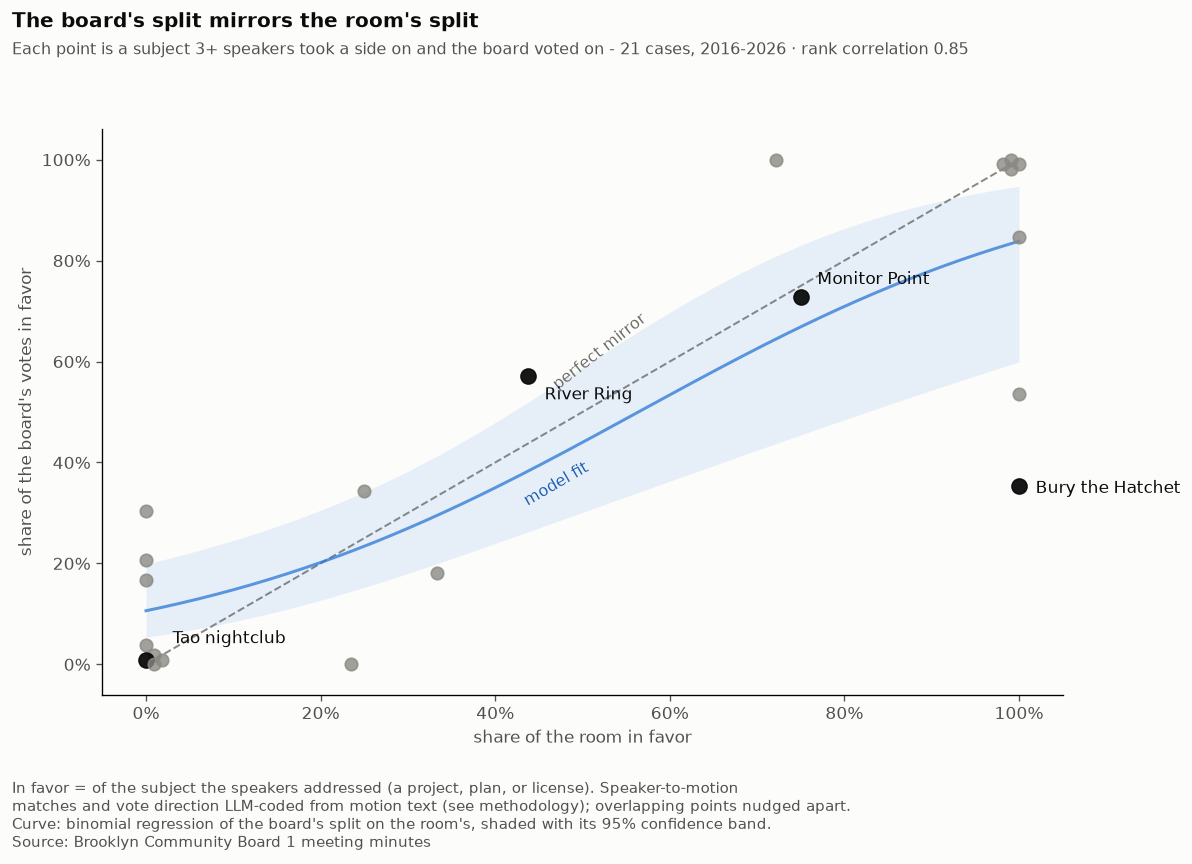

In [6]:
#| fig-alt: "Scatter plot of 21 subjects comparing the share of the room in favor against the share of the board's votes in favor. Points hug the diagonal; a regression curve with a 95 percent confidence band rises from about 11 percent board support when the room is unanimously against to 84 percent when unanimously in favor. River Ring and Bury the Hatchet sit off the line."
#| column: body-outset
# Widen the net: every case where 3+ speakers took a side on a subject the
# board then voted on. The speaker-to-motion match and the motion's direction
# (does 'yes' side with the speakers' 'for'?) were coded by Claude Code from
# the motion text as part of the ETL; procedural motions and motions whose
# direction can't be recovered from the text are excluded.
# Columns: room for/against, board for/against.
MIRROR = pd.DataFrame([
    ("Metropolitan Ave bike lanes",    "2016-10-13",  3,  0, 34,  0),
    ("13-15 Greenpoint Ave amendment", "2017-01-10",  0,  7,  1, 25),
    ("Wburg Bridge access plan",       "2017-03-21",  5,  0, 29,  0),
    ("Transmitter Park concession",    "2017-05-09",  0,  4,  0, 31),
    ("Painting Lounge license",        "2017-11-14",  0,  4,  7, 16),
    ("Bury the Hatchet license",       "2018-12-11",  3,  0, 12, 22),
    ("10 Hope St license",             "2018-12-11",  1,  3, 11, 21),
    ("St. Paul's restoration",         "2019-01-08",  4,  0, 40,  0),
    ("Women's swim hours",             "2019-11-12",  4,  0, 22,  4),
    ("Meeker parking plan",            "2020-11-10",  0,  6,  0, 10),
    ("Meeker safety plan",             "2021-05-11", 13,  5, 14,  0),
    ("McGuinness redesign",            "2021-06-08", 24,  0,  8,  0),
    ("River Ring",                     "2021-09-14", 14, 18, 20, 15),
    ("BQE metered parking",            "2022-02-08",  1,  2,  2,  9),
    ("Monitor/Kingsland bike lanes",   "2022-06-07",  4, 13,  0, 29),
    ("Tao nightclub",                  "2024-06-18",  0, 10,  0, 31),
    ("Bedford Slip open street",       "2024-09-10",  0,  7,  6, 23),
    ("Maiz license",                   "2024-10-08",  0,  5,  0, 25),
    ("Baby's All Right sheds",         "2025-01-14",  0,  3,  6, 30),
    ("Monitor Point",                  "2026-02-10", 24,  8, 24,  9),
    ("Berry St traffic study",         "2026-06-09",  4,  0, 15, 13),
], columns=["label", "date", "rf", "ra", "bp", "ba"])
MIRROR["room"] = MIRROR.rf / (MIRROR.rf + MIRROR.ra)
MIRROR["board"] = MIRROR.bp / (MIRROR.bp + MIRROR.ba)

from scipy.stats import spearmanr
import statsmodels.api as sm
rho, _ = spearmanr(MIRROR.room, MIRROR.board)
mglm = sm.GLM(np.column_stack([MIRROR.bp, MIRROR.ba]),
              sm.add_constant(MIRROR.room),
              family=sm.families.Binomial()).fit(cov_type="HC1")
# headcount check, quoted in the prose: once the room's split is known, does
# the size of the crowd add anything? (null - asserted in the guard cell)
mglm_n = sm.GLM(np.column_stack([MIRROR.bp, MIRROR.ba]),
                sm.add_constant(np.column_stack([MIRROR.room,
                                                 np.log(MIRROR.rf + MIRROR.ra)])),
                family=sm.families.Binomial()).fit(cov_type="HC1")

fig, ax = plt.subplots(figsize=(10, 6.4), dpi=120)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)
ax.plot([0, 1], [0, 1], ls="--", lw=1.2, color=GRAY, zorder=1)
ax.annotate("perfect mirror", (0.52, 0.545), fontsize=9.5, color=GRAYTXT,
            rotation=38, ha="center")
_xx = np.linspace(0, 1, 200)
_fit = mglm.get_prediction(sm.add_constant(_xx)).summary_frame()
ax.fill_between(_xx, _fit["mean_ci_lower"], _fit["mean_ci_upper"],
                color=BLUE, alpha=0.10, lw=0, zorder=1)
ax.plot(_xx, _fit["mean"], color=BLUE, lw=1.8, alpha=0.75, zorder=2)
ax.annotate("model fit", (0.47, 0.315), fontsize=9.5, color=BLUETXT,
            rotation=30, ha="center")

# exactly-overlapping points get a tight nudge - just enough to show the
# pile-up without reading as distinct values; rings pulled inside at the edges
pts = MIRROR.copy()
_J = 0.009
for (x, y), g in pts.groupby(["room", "board"]):
    if len(g) > 1:
        cx = x - _J * ((x > 0.99) - (x < 0.01))
        cy = y - _J * ((y > 0.99) - (y < 0.01))
        for k, idx in enumerate(g.index):
            ang = 2 * np.pi * k / len(g)
            pts.loc[idx, "room"] = cx + _J * np.cos(ang)
            pts.loc[idx, "board"] = cy + _J * np.sin(ang)

named = {"Tao nightclub": (16, 10), "River Ring": (10, -14),
         "Monitor Point": (10, 8), "Bury the Hatchet license": (10, -4)}
for _, p in pts.iterrows():
    hot = p.label in named
    ax.plot(p.room, p.board, "o", ms=9 if hot else 7.5,
            color=INK if hot else GRAY, alpha=0.95 if hot else 0.8, zorder=3)
    if hot:
        dx, dy = named[p.label]
        ax.annotate(p.label.replace(" license", ""), (p.room, p.board),
                    xytext=(dx, dy), textcoords="offset points",
                    fontsize=10, color=INK)

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.06, 1.06)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlabel("share of the room in favor", fontsize=10, color=INK2)
ax.set_ylabel("share of the board's votes in favor", fontsize=10, color=INK2)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(colors=INK2)
fig.suptitle("The board's split mirrors the room's split",
             fontsize=12, color=INK, x=0.01, ha="left", fontweight="bold")
fig.text(0.01, 0.925, f"Each point is a subject 3+ speakers took a side on and the board "
         f"voted on - {len(MIRROR)} cases, 2016-2026 · rank correlation {rho:.2f}",
         fontsize=9.5, color=INK2)
fig.text(0.01, -0.02, "In favor = of the subject the speakers addressed (a project, plan, or license). Speaker-to-motion\n"
         "matches and vote direction LLM-coded from motion text (see methodology); overlapping points nudged apart.\n"
         "Curve: binomial regression of the board's split on the room's, shaded with its 95% confidence band.\n"
         + SRC,
         fontsize=9, color=INK2, va="top")
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

The rank correlation is 0.85, and in 19 of 21 cases the board's majority landed on the same side as the room's majority. Running a regression on these points: a room of speakers fully against a project is associated with 11% of the board voting in favor. A room unanimously in favor, roughly 84%. The confidence band is denoted by the blue band - given the limited dataset the band is failr large. I also ran a regression to see if the number of speakers present has any impact on the board's vote, but there was no statistical evidence of an effect.

There are two outliers worth naming. River Ring had more of the board in favor than the speakers, but still the vote wasn't far from the room's ratio. The other is Bury the Hatchet, an axe-throwing bar. Three speakers advocated for it and nobody was against; the board denied the license 22-12. The CB1 minutes explain the situation: all three speakers on this motion were from the applicant's own team, and the committee's support was conditional on a letter from the neighboring block association that was never delivered. So this one wasn't really a case of the board deviating from the community, but the board voting in favor of the community despite zero community presence.

An important statistical disclaimer: all of the above analysis discusses correlation, not causation. We do not have the ability to run experiments and understand the counterfactual. We cannot prove that speaker turnout caused a vote to turn out a certain way.

In [7]:
# Prose-consistency guard: every number quoted in the text, recomputed.
# The render fails here if a re-extraction drifts the data out from under the prose.
assert len(MAIL) == 1707, len(MAIL)              # "1,707 letters and emails"
assert int(MAIL.outgoing.sum()) == 464           # "464 ... the board's own outgoing mail"
assert len(INCOMING) == 1243, len(INCOMING)      # "1,243 pieces of incoming correspondence"
_p24 = (INCOMING.date >= "2024").mean()
assert abs(_p24 - 0.724) < 0.005, _p24           # "72% land from 2024 on"
assert tao_mail == (219, 1), tao_mail            # "219 emails against ... one in favor"
assert mp_mail == (81, 10), mp_mail              # "81-10 against the rezoning"
assert berry_mail == (0, 4), berry_mail          # berry mail unanimous for the study
assert len(_about(INCOMING[INCOMING.date == "2026-06-09"], "berry st")) == 4  # "drew four letters"
assert len(MIRROR) == 21                         # "21 points"
assert round(rho, 2) == 0.85                     # "rank correlation is 0.85"
assert ((MIRROR.room > 0.5) == (MIRROR.board > 0.5)).sum() == 19  # "19 of 21"
assert mglm_n.pvalues[2] > 0.05, mglm_n.pvalues[2]  # "no statistical evidence" for headcount
_e = mglm.predict(sm.add_constant(np.array([0.0, 1.0])))
assert 0.05 < _e[0] < 0.20 and 0.60 < _e[1] < 0.95  # "11%" / "roughly 84%"
print("prose-consistency checks passed:",
      len(MAIL), len(INCOMING), f"{_p24:.1%}", tao_mail, mp_mail)

prose-consistency checks passed: 1707 1243 72.4% (219, 1) (81, 10)


## So what role can the community play in developing this land into a park?

This analysis largely focuses on one lever for prompting development in this park: community advocates working directly with their community board through mail or public speaking. I'd be tempted to say the park movement should just flood the community board with speaker requests in order to influence the board vote. However, given that the board pre-screens the speakers, this could just be a confounding variable: who the board permits to speak could be a predictor of how they are inclined to vote.

It's also important to note one observation we did not analyze above: CB1 meeting minutes show conditions attached to the approvals that drew the most advocacy. A few examples from Monitor Point: the esplanade completion timeline, a certificate-of-occupancy condition tied to the promised Monitor Museum, and park maintenance money. I'll dig into this in a future post to see if we can tie these conditions to specific speakers more widely.

![One of the fenced-off lots at the park's edge, July 2026: cracked asphalt, weeds, and a skyline view going unused. Photo: author](images/lots_fence.jpg){.column-body-outset fig-alt="A chain-link fence around a vacant lot of cracked asphalt and weeds, with the Manhattan skyline visible across the river."}

## Methodology

The dataset comes from the PDF meeting minutes CB1 posts publicly - 138 files covering 110 meetings from 2016 to 2026, about 22,000 pages. I extracted structured records (votes, liquor licenses, public speakers) with a custom ETL pipeline using LLMs hosted on AWS Bedrock. I created a verification framework and hand-verified a subset of data points from three sample meetings against the original PDFs: vote tallies matched 38 of 38, license records 144 of 144, and speaker recall was 97%. Every extracted record keeps a verbatim quote from the source PDF, so any claim in this post can be traced back to a page. One extraction gap surfaced during this analysis - the September 2021 roll-call section, including the River Ring votes, had been misfiled as an attachment. I recovered it by hand from the minutes text, with the fix documented in the dataset.

A note on the tracer term: the first chart counts "waterfront" because that's the planning term - the 2005 deal is the North Brooklyn waterfront rezoning. I checked it against the alternatives ("park", "Bushwick Inlet", "rezoning", "Monitor Point", "open space", "greenway", "esplanade") over the same full-text index. "Waterfront" appears in 97 of 110 meetings, and its three biggest spikes are exactly the three events called out on the chart - with no tuning. The alternatives each fail in their own way: "park" matches every playground in the district (plus "parking"), "Monitor Point" doesn't exist as a name before 2025, and "Bushwick Inlet" triples in one meeting because a single email template was re-sent 100+ times. The comparison table is in the analysis notebook.

Two disclaimers:

1. Everything stated above is association, not causation: big projects generate both turnout and division, and this data can't say which causes which. The mirror-chart regression comes with a wide confidence band at 21 points, and its speaker-to-motion matches were coded by Claude Code from the motion text as part of the ETL, not hand-verified.
2. Letters and emails are split out of the minutes' attachment pages by an LLM pass; the full dataset ships with the repo (data/mail_items.jsonl - one record per item with a 1,200-character window, email addresses redacted). This replaced an earlier regex splitter that undercounted, especially before 2024 where scans and looser formatting hid roughly two-thirds of the mail. Duplicates and the board's own outgoing letters are excluded from all counts. Stances are keyword-coded with negation handling; when a letter argues both directions, the earlier match wins - writers lead with their stance. Every letter counted as "for" in the four charted motions was read and confirmed, along with every keyword-unclear item and a 25-letter sample of the against class (zero errors); the confirmations are documented in data/mail_adjudications.jsonl. Letters without a clear stance are excluded from the tallies. Correspondence is only bound into the minutes in volume from about 2024, so pre-2024 mail counts are best read as floors.

The full pipeline, analysis notebooks, and the extracted dataset are on GitHub: [blowenstein0/cb1-minutes-analysis](https://github.com/blowenstein0/cb1-minutes-analysis).

In [8]:
# Why "waterfront": tracer-term robustness check. The printed table stays in
# the notebook (stream output is stripped from the blog render). The asserts
# guard the Methodology prose - nbconvert fails here if a re-extraction
# shifts the numbers.
import re as _re

_cands = [
    ("waterfront", r"waterfront"),
    ("park (word)", r"\bpark\b"),
    ("parking", r"parking"),
    ("bushwick inlet", r"bushwick inlet"),
    ("rezon*", r"rezon"),
    ("monitor point", r"monitor point"),
    ("open space", r"open space"),
    ("greenway", r"greenway"),
    ("esplanade", r"esplanade"),
]
_rows = []
for _label, _pat in _cands:
    _per = {m: len(_re.findall(_pat, t)) for m, t in lower.items()}
    _per = {m: n for m, n in _per.items() if n}
    _top = sorted(_per.items(), key=lambda kv: -kv[1])[:3]
    _rows.append((_label, sum(_per.values()), len(_per),
                  [(dates[m], n) for m, n in _top]))
print(f"{'term':<16}{'total':>7}{'meetings':>9}  top-3 (date, n)")
for _label, _total, _nm, _top in _rows:
    print(f"{_label:<16}{_total:>7}{_nm:>9}  {_top}")

_wf = _rows[0]
assert _wf[0] == "waterfront"
assert _wf[2] == 97, _wf[2]  # "appears in 97 of 110 meetings"
assert [d for d, _ in _wf[3]] == ["2026-01-20", "2024-06-18", "2023-02-07"], _wf[3]
assert [n for _, n in _wf[3]] == [276, 189, 113], _wf[3]

term              total meetings  top-3 (date, n)
waterfront         1981       97  [('2026-01-20', 276), ('2024-06-18', 189), ('2023-02-07', 113)]
park (word)        6611      108  [('2024-06-18', 980), ('2026-01-20', 570), ('2022-03-08', 231)]
parking            2919      105  [('2026-06-09', 180), ('2024-06-18', 97), ('2025-06-10', 96)]
bushwick inlet     1485       94  [('2024-06-18', 602), ('2026-01-20', 270), ('2025-06-10', 63)]
rezon*             1136       77  [('2026-01-20', 295), ('2025-05-13', 80), ('2025-06-10', 50)]
monitor point       620        8  [('2026-01-20', 314), ('2026-02-10', 145), ('2025-06-10', 135)]
open space          913       83  [('2026-01-20', 106), ('2025-06-10', 51), ('2021-04-13', 41)]
greenway            213       30  [('2026-03-10', 66), ('2026-04-14', 44), ('2020-06-24', 13)]
esplanade            87       24  [('2022-03-08', 10), ('2020-10-13', 9), ('2026-02-10', 9)]
